In [7]:
import sys
sys.path.append('..')

In [8]:
import pandas as pd
from utils.data_enedis_ademe import DataEnedisAdeme
from utils.fonctions import load_parquet_data, normalize_colnames_list
from src.artifacts.data_processing import Nettoyage

#### Consommation d'électricité annuelle résidentielle par adresse

*Le jeu de données présente la consommation électrique annuelle des adresses de 10 logements ou plus. Un logement correspond à un point de livraison (ou PDL) de type résidentiel.<br>Les données sont mises à disposition à titre purement indicatif sans garantie quant au degré de fiabilité des adresses. Enedis ne saurait, par conséquent, être tenue responsable en cas de défaut de fiabilité.<br>À partir de 2021 et suite à un changement dans le référentiel des adresses, la normalisation de celles-ci peut faire apparaitre des écarts avec les années précédentes.*

In [3]:
tmp_url = "https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?select=segment_de_client%2C%20annee%2C%20count\
    (code_iris)%20as%20nb%2C%20min(nombre_de_logements)%20as%20nb_min_logements%2C%20max(nombre_de_logements)%20as%20nb_max_logements&group_by=segment_de_client%2C%20annee&limit=20"

DataEnedisAdeme().load_get_data_pandas(tmp_url)

,segment_de_client,annee,nb,nb_min_logements,nb_max_logements
0,RESIDENTIEL,2018-01-01T00:00:00+00:00,391099,10,1189
1,RESIDENTIEL,2019-01-01T00:00:00+00:00,399791,10,1124
2,RESIDENTIEL,2020-01-01T00:00:00+00:00,405605,10,1435
3,RESIDENTIEL,2021-01-01T00:00:00+00:00,407053,10,1189
4,RESIDENTIEL,2022-01-01T00:00:00+00:00,394100,10,1190
5,RESIDENTIEL,2023-01-01T00:00:00+00:00,397398,10,1196


*Avec ceci on voit que les adresses Enedis sont des logements 'residentiels' avec au moins 10 logements et au plus +de 1000 logements. Une fois la correspondance faite avec la base de l'ADEME - DPE depuis 2021 on le dataset suivant :*

In [4]:
db = DataEnedisAdeme()
tmp_df = db.extract_year_rows(year=2018, rows=5)
tmp_df.head(3)

 https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?where=annee%20%3D%20date'2018'&limit=5


,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,Configuration_installation_chauffage_n°1_ademe,...,x_enedis_with_ban,y_enedis_with_ban,city_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,_type_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban
0,1764.6,150.0,1610.4,Dijon,108.4,1610.4,0,1764.6,619.0,Installation de chauffage simple,...,854384.3,6696686.03,Dijon,"21, Côte-d'Or, Bourgogne-Franche-Comté",housenumber,0.62448,Rue Paul Verlaine,address,5.045308,47.352511
1,3509.2,200.0,2006.2,Dijon,216.5,2006.2,0,3509.2,1188.6,Installation de chauffage simple,...,854384.3,6696686.03,Dijon,"21, Côte-d'Or, Bourgogne-Franche-Comté",housenumber,0.62448,Rue Paul Verlaine,address,5.045308,47.352511
2,5515.0,200.0,1842.6,Dijon,347.5,1842.6,0,5515.0,1155.3,Installation de chauffage simple,...,854384.3,6696686.03,Dijon,"21, Côte-d'Or, Bourgogne-Franche-Comté",housenumber,0.62448,Rue Paul Verlaine,address,5.045308,47.352511


*Echantillon pour l'étude : périmètre Paris 2018*

In [9]:
# df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet', engine='pyarrow')
df = load_parquet_data('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')
df.head()

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..


,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,nom_commune_ban_ademe,emission_ges_chauffage_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,cout_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,25827.1,0.0,2621.9,Paris,4670.2,0.0,2621.9,0,25827.1,1962.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
1,1318.3,100.0,1153.0,Paris,79.4,NaN,1153.0,0,1318.3,458.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
2,49222.4,100.0,1772.3,Paris,8796.8,3046.7,0.0,0,47488.7,3705.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
3,2468.6,100.0,1150.6,Paris,153.9,NaN,1150.6,0,2468.6,598.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
4,2526.3,100.0,1132.2,Paris,157.8,NaN,1132.2,0,2526.3,602.4,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None


# Exploration

In [6]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [7]:
class preprocessing :
    def __init__(self, df):
        self.df = df.copy()
        self.cast_object_columns_step = False 
        
    def get_entropy(self, pk, L):
        op= - (pk * np.log(pk) / np.log(L)).sum()
        return op

    def delete_colnan (self, tauxseuil):
        print("delete_colnan")
        print("Le dataframe contient initialement {} colonnes et {} lignes.".format(len(self.df.columns), len(self.df)))
        print("Start processing : columns identification ...")
        nanames = []
        entro = []
        extra = normalize_colnames_list(["Code_INSEE_(BAN)_ademe","Code_postal_(brut)_ademe","Code_postal_(BAN)_ademe","Numéro de voie_enedis_with_ban",
                "Nombre de logements_enedis_with_ban","Tri des adresses_enedis_with_ban","postcode_enedis_with_ban","citycode_enedis_with_ban"]) #"Code IRIS_enedis_with_ban",
        for c in self.df.columns:
            tauxnan = round(self.df[c].isna().sum()/len(self.df),2)
            pk = df[c].value_counts(normalize=True, dropna = False).values
            entropy = round(self.get_entropy(pk, len(self.df)),2)
            if tauxnan >= tauxseuil:
                nanames.append(c)
                # print("***", c, "***")
                # print(tauxnan)
            if c[0]=="_" and "geo" not in c:
                extra.append(c)
            if entropy == 1 or entropy == 0:
                entro.append(c)
        print("Il y a {} colonnes vides à, au moins, {}% , {} colonnes avec une entropy de 0 ou 1 et {} colonnes inutiles".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
        print("Start processing : columns deleting ...")
        self.df=self.df.drop(nanames+entro+extra, axis=1).drop_duplicates()
        print("Done deleting columns")
        print("Il reste {} colonnes et {} lignes.".format(len(self.df.columns), len(self.df)))
        print(self.df.info())
        return self

    
    def cast_object_columns(self):
        print("Start processing : columns encoding ...")
        if not self.cast_object_columns_step:
            cols_obj = self.df.select_dtypes(include='O').columns
            for c in cols_obj:
                # self.df[c] = self.df[c].str.replace(',', '.')
                # self.df[c] = self.df[c].fillna(-999999)
                try:
                    self.df[c] = pd.to_numeric(self.df[c].str.replace(',','.'), errors='raise')
                except Exception as e:
                    try:
                        self.df[c] = pd.to_datetime(self.df[c])
                    except Exception as e:
                        self.df[c] = self.df[c].astype('string')
            print("Casting done...")
            self.cast_object_columns_step = True
        print(self.df.info())
        print("done cast_object_columns")
        return self
    

    def fillnan(self):
        # print("fillnan")
        print(self.df.info())
        # col_fill_median = []
        # col_fill_mean = []
        for col in self.df.select_dtypes(include ='float').columns:
            if col not in normalize_colnames_list(["Coordonnée_cartographique_X_(BAN)_ademe","Coordonnée_cartographique_Y_(BAN)_ademe","Version_DPE_ademe","Année_construction_ademe"]): # les colonnes à ne pas modifier
                if self.df[col].isna().any():
                    # print(self.df[col].dtypes)
                    Q1 = self.df[col].quantile(0.25)
                    Q3 = self.df[col].quantile(0.75)
                    IQR = Q3 - Q1
                    born_inf =(self.df[col]<(Q1-1.5*IQR)).value_counts() # le nombre de valeurs en dessous de la brone inférerieure de l'écart interquartile
                    born_sup = (self.df[col]>(Q3+1.5*IQR)).value_counts() # le nombre de valeurs au dessus de la brone supérieure de l'écart interquartile
                    # permet d'identifier les outliers
                    try:
                        born_inf[1] # si la borne inférieure existe, s'il y a des Trues
                        #col_fill_median.append(col)
                        self.df[col].fillna(self.df[col].median(), inplace=True ) # on remplace les valeurs manquantes par la médiane
                        # print("le type",self.df[col].dtypes)
                    except Exception as e:
                        try:
                            born_sup[1] # si la borne supérieure existe, s'il y a des Trues
                            #col_fill_median.append(col)
                            self.df[col].fillna(self.df[col].median(), inplace=True) # on remplace les valeurs manquantes par la médiane
                            # print("le type",self.df[col].dtypes)
                        except Exception as e:
                            #col_fill_mean.append(col)
                            # self.df[col].fillna(self.df[col].mean, inplace=True)
                            self.df[col] = self.df[col].fillna(self.df[col].mean()) # on remplace les valeurs manquantes par la moyenne car il n'y a pas d'outliers
                            # print("le type",self.df[col].dtypes)
            else:
                pass
        # print("le nomnbre de colonnes traitées:", len(df.select_dtypes(['int','float']).columns))
        # print(len(col_fill_median))
        # print(len(col_fill_mean))
        # print(self.df.info())
        print("done fillnan")
        return self
    
    def delete_datetime(self):
        print("delete_datetime")
        self.df.drop(self.df.select_dtypes(include='datetime').columns, axis=1, inplace=True)
        return self
    

In [8]:
df_clean_ = preprocessing(df).delete_colnan(0.9).cast_object_columns().fillnan().delete_datetime().df
# df_clean_col = df_clean.drop(columns=df_clean.select_dtypes(include='datetime').columns)
# df_clean_col.info()
print(f'il reste {len(df_clean_.columns)} colonnes et {len(df_clean_)} lignes.') #il reste 171 colonnes et 444192 lignes.

delete_colnan
Le dataframe contient initialement 280 colonnes et 464576 lignes.
Start processing : columns identification ...
Il y a 76 colonnes vides à, au moins, 90.0% , 55 colonnes avec une entropy de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Done deleting columns
Il reste 175 colonnes et 444192 lignes.
<class 'pandas.core.frame.DataFrame'>
Index: 444192 entries, 0 to 464575
Columns: 175 entries, conso_chauffage_depensier_e_finale_ademe to lat_enedis_with_ban
dtypes: float64(104), int64(1), object(70)
memory usage: 596.4+ MB
None
Start processing : columns encoding ...
Casting done...
<class 'pandas.core.frame.DataFrame'>
Index: 444192 entries, 0 to 464575
Columns: 175 entries, conso_chauffage_depensier_e_finale_ademe to lat_enedis_with_ban
dtypes: datetime64[ns](4), float64(106), int64(1), string(64)
memory usage: 596.4 MB
None
done cast_object_columns
<class 'pandas.core.frame.DataFrame'>
Index: 444192 entries, 0 to 464575
Columns: 175 entries, conso_c

In [10]:
# test2 class nettoyage
# rom src.artifacts.data_processing import Nettoyage
pipeline = Nettoyage(df)
pipeline.run(use_entropy_selection=True)
test2=pipeline.df
print(f'il reste {len(test2.columns)} colonnes et {len(test2)} lignes.')
test2.info()

-> Delete cols mano..
-> Delete NaN cols..
Le dataframe contient initialement 251 colonnes et 464576 lignes.
Start processing : columns identification..
Il y a 76 colonnes vides à au moins, 90.0%, 55 colonnes avec une entropie de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Il reste 147 colonnes et 375547 lignes.
-> Start object columns auto casting..
End casting
-> Fill pd.NA for float dtypes..
Done fillnan !
Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['deperditions_ponts_thermiques_ademe', 'emission_ges_5_usages_energie_ndeg1_ademe', 'conso_5_usages_e_finale_energie_ndeg1_ademe', 'cout_total_5_usages_energie_ndeg2_ademe', 'surface_chauffee_installation_chauffage_ndeg1_ademe', 'conso_ecs_e_finale_ademe', 'cout_chauffage_depensier_ademe', 'conso_refroidissement_e_primaire_ademe', 'conso_e_finale_depensier_generateur_ecs_ndeg1_ademe', 'conso_ecs_e_primaire_ademe', 'emission_ges_ecs_ademe', 'conso_e_finale_generateur_ecs_ndeg1_ademe', 'conso_e

In [4]:
df_ = df.copy()

In [5]:
df_.shape

(464576, 280)

In [11]:
import numpy as np

def get_entropy(pk, L):
    op= - (pk * np.log(pk) / np.log(L)).sum()
    return op    

def get_entropy_by_colname(data, colname):
    pk = data[colname].value_counts(normalize=True, dropna = False).values
    return round(get_entropy(pk, len(data)), 2)

col = [c for c in df_.select_dtypes("float").columns]
correlation_matrix = df_[col].corr()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# trouver les colonnes ayant une corrélation supérieure au seuil
to_drop = []
for column in upper_triangle.columns:
    high_corr = upper_triangle[column][abs(upper_triangle[column]) > 0.9].index.tolist()
    for col in high_corr:
        if get_entropy_by_colname(df_, column) > get_entropy_by_colname(df_, col):
            to_drop.append(col)
        else:
            to_drop.append(column)

In [15]:
280 - len(set(to_drop))

201

In [6]:
# test class nettoyage
# rom src.artifacts.data_processing import Nettoyage
pipeline = Nettoyage(df_)
pipeline.run(use_target_correlation_selection=True)
test=pipeline.df
print(f'il reste {len(test.columns)} colonnes et {len(test)} lignes.')
test.info()

-> Delete cols mano..
-> Delete NaN cols..
Le dataframe contient initialement 251 colonnes et 464576 lignes.
Start processing : columns identification..
Il y a 76 colonnes vides à au moins, 90.0%, 55 colonnes avec une entropie de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Il reste 147 colonnes et 375547 lignes.
-> Start object columns auto casting..
End casting
-> Fill pd.NA for float dtypes..
Done fillnan !


AttributeError: 'Nettoyage' object has no attribute 'get_corr_with_target'

Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['emission_ges_chauffage_ademe', 'cout_total_5_usages_ademe', 'conso_e_finale_depensier_installation_ecs_ademe', 'emission_ges_eclairage_ademe', 'conso_ecs_depensier_e_finale_ademe', 'cout_ecs_ademe', 'surface_habitable_desservie_par_installation_ecs_ademe', 'cout_eclairage_ademe', 'cout_total_5_usages_energie_ndeg1_ademe', 'conso_chauffage_e_primaire_ademe', 'conso_eclairage_e_primaire_ademe', 'emission_ges_5_usages_energie_ndeg1_ademe', 'emission_ges_ecs_energie_ndeg1_ademe', 'conso_5_usages_e_finale_ademe', 'conso_refroidissement_e_primaire_ademe', 'emission_ges_ecs_depensier_ademe', 'emission_ges_chauffage_energie_ndeg1_ademe', 'conso_e_finale_depensier_generateur_ecs_ndeg1_ademe', 'emission_ges_ecs_ademe', 'cout_ecs_energie_ndeg2_ademe', 'cout_ecs_energie_ndeg1_ademe', 'conso_ecs_e_finale_ademe', 'emission_ges_5_usages_ademe', 'conso_eclairage_e_finale_ademe', 'conso_chauffage_generateur_ndeg1_installation_ndeg1_ademe',

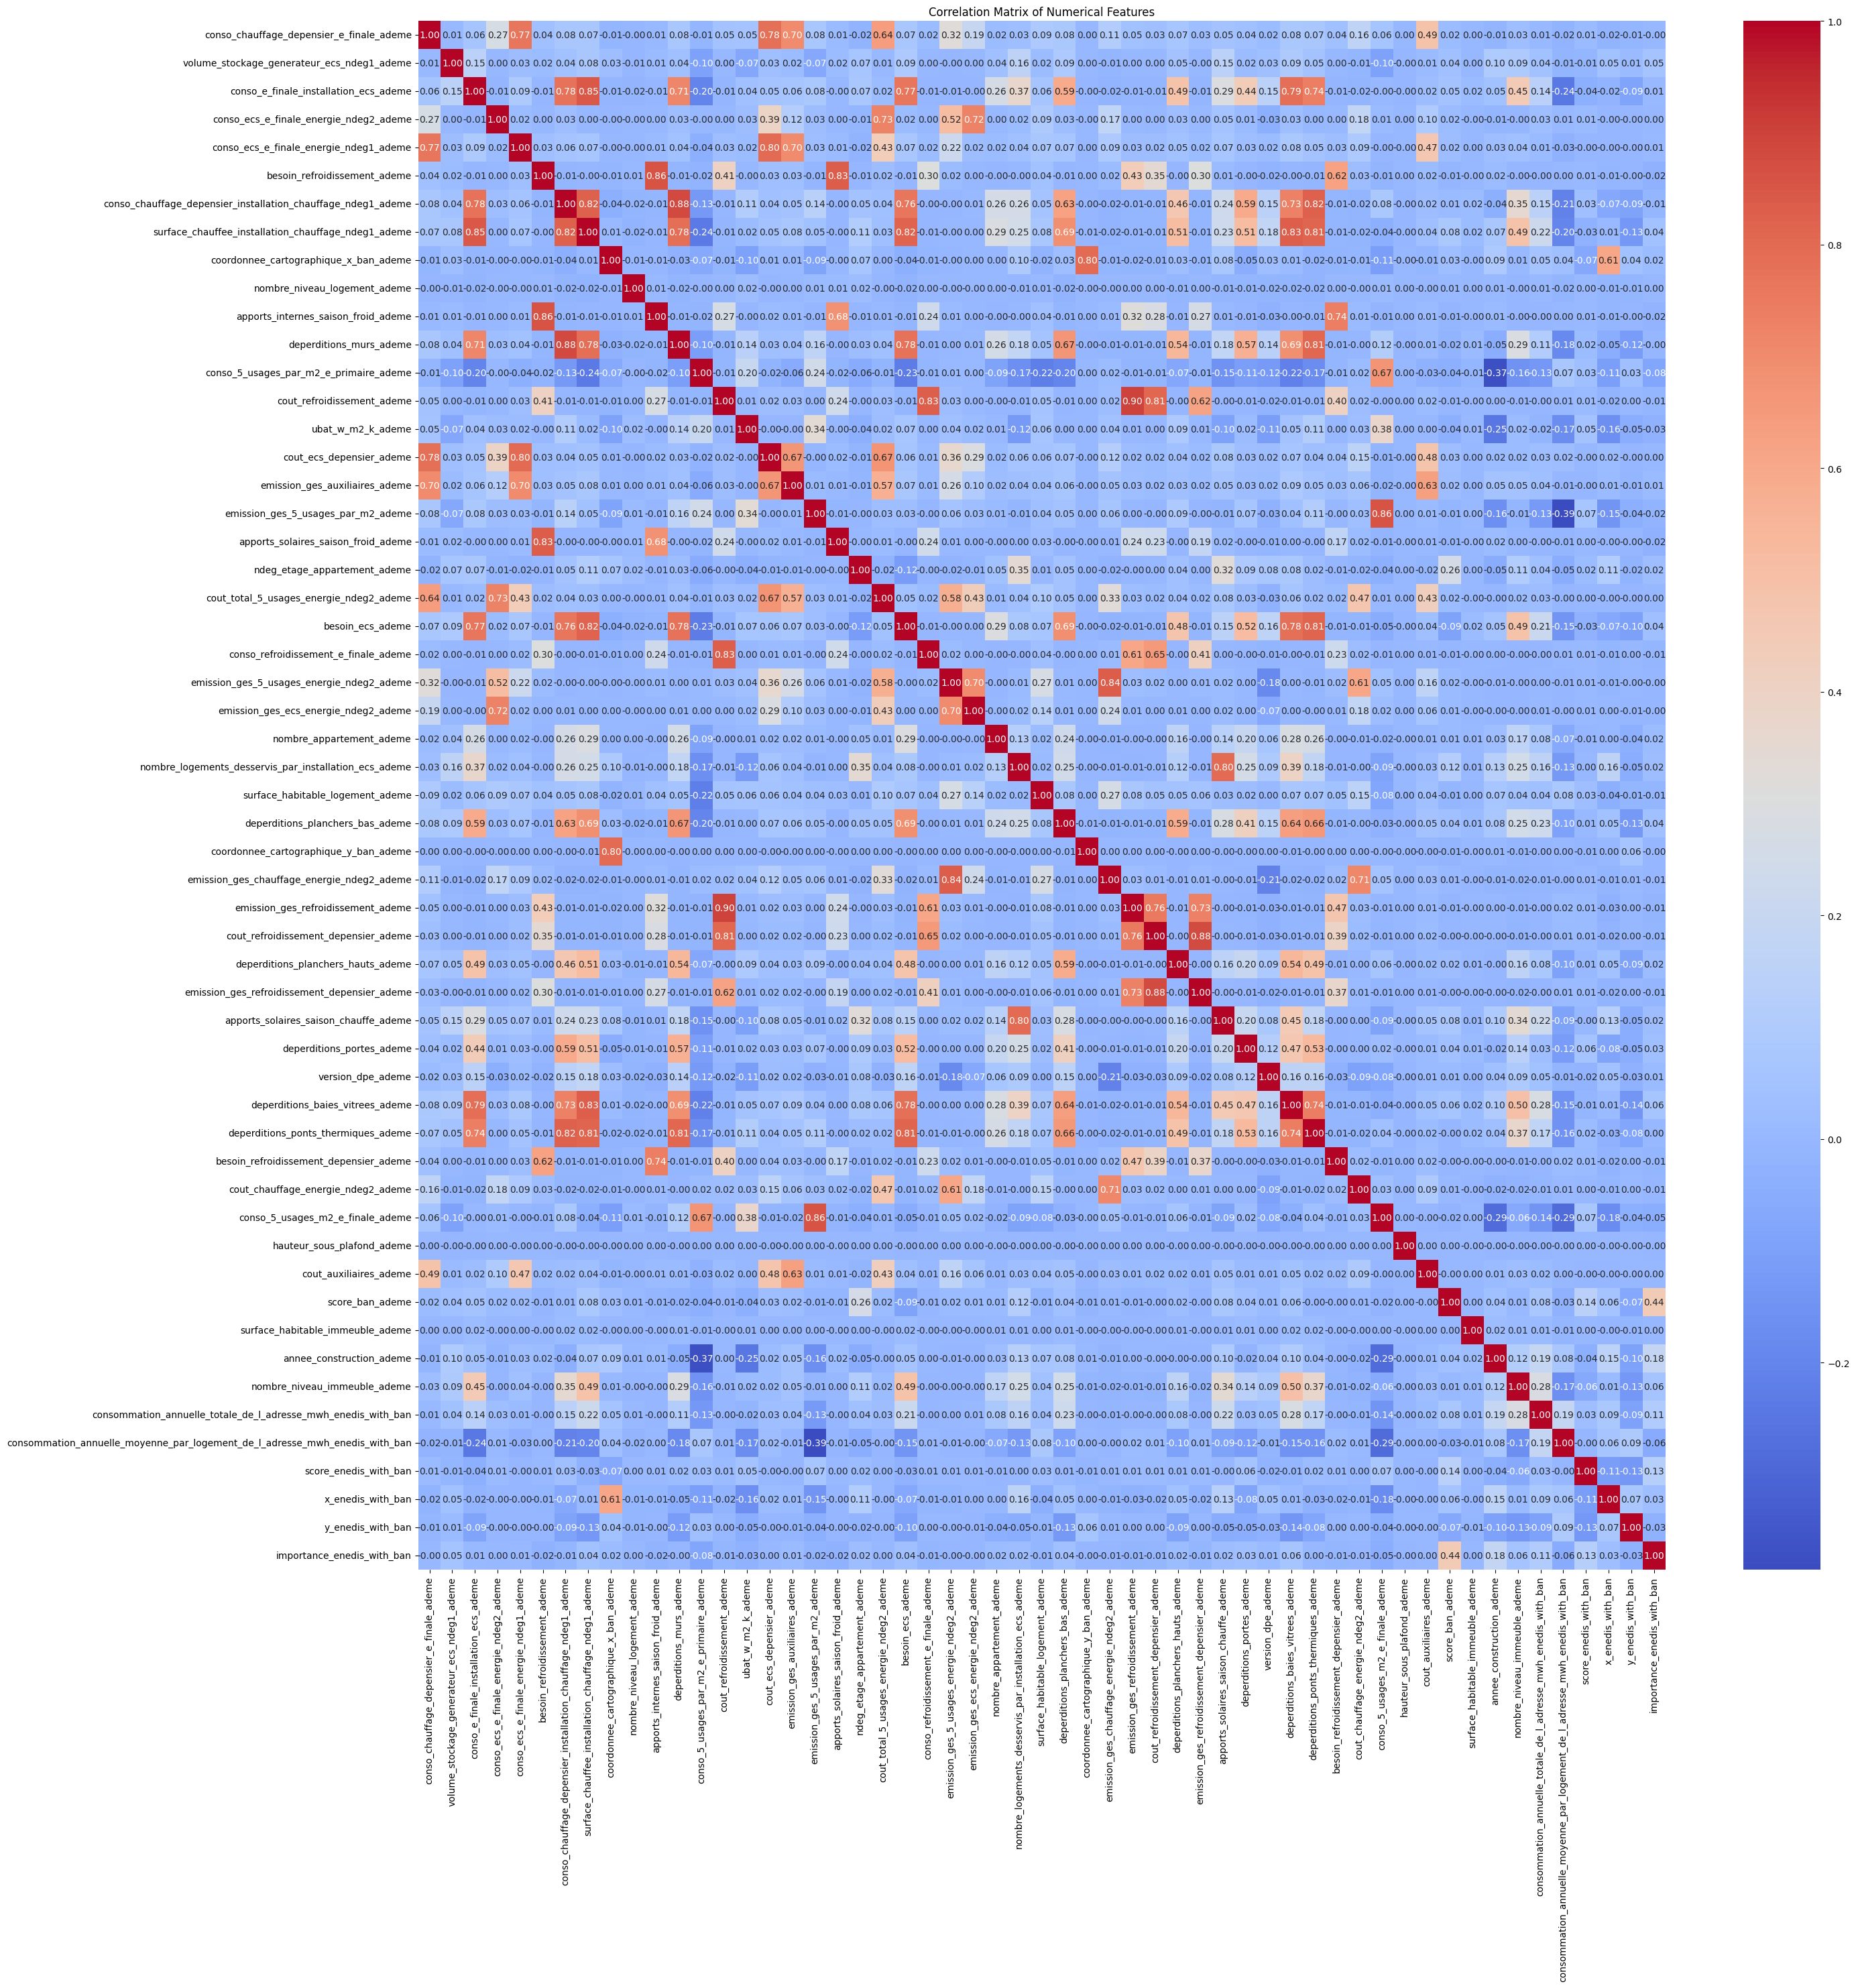

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def clean_correlation(df, seuil):

    col = [c for c in df.select_dtypes("float").columns ]
    correlation_matrix = df[col].corr()

    threshold = seuil  # le seuil de colinéarité
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    # Étant donné que la matrice est symétrique on ne garde que la partie supérieure pour éviter les doublons.

    # Trouver les colonnes ayant une corrélation supérieure au seuil
    to_drop = [column for column in upper_triangle.columns if any(abs(upper_triangle[column]) > threshold)]
    print(f"Les colonnes suivantes ont une corrélation supérieure à {threshold} : {to_drop}")

    # Supprimer les colonnes colinéaires
    df = df.drop(columns=to_drop)

    print(f"Les colonnes suivantes ont été supprimées : {to_drop}")
    print(f'il reste {len(df.columns)} colonnes')

    #conso_clean_col = [c for c in df.columns if "conso" in c.lower()]
    col = [c for c in df.select_dtypes("float").columns ]
    correlation_matrix = df[col].corr()

    plt.figure(figsize=(30, 30))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    # plt.show()
    return df

df_clean = clean_correlation(df_clean_, 0.9)

In [85]:
# garder l'arrondissement
import re
def extract_digit(x):
    return re.sub(r'\D', '', str(x))

df_clean["arrondissement"] = df_clean["district_enedis_with_ban"].apply(extract_digit).astype('string')
# supprimer les colonnes inutiles apriori
to_drop = normalize_colnames_list(["district_enedis_with_ban","street_enedis_with_ban", "name_enedis_with_ban", "id_BAN_enedis_with_ban", "housenumber_enedis_with_ban", "label_enedis_with_ban", "full_adress_enedis_with_ban",
           "adresse_enedis_with_ban","Libellé de voie_enedis_with_ban", "Type de voie_enedis_with_ban", "Nom IRIS_enedis_with_ban", "N°_DPE_immeuble_associé_ademe", "Nom__rue_(BAN)_ademe",
           "Identifiant__BAN_ademe","Complément_d'adresse_bâtiment_ademe", "Adresse_brute_ademe", "N°DPE_ademe", "N°_voie_(BAN)_ademe", "Complément_d'adresse_logement_ademe",
           "Adresse_(BAN)_ademe","_geopoint_ademe","Statut_géocodage_ademe", "Description_installation_ECS_ademe", "Description_générateur_ECS_n°1_ademe",
           "Description_générateur_chauffage_n°1_installation_n°1_ademe", "Description_installation_chauffage_n°1_ademe", "score_enedis_with_ban", "x_enedis_with_ban", "y_enedis_with_ban","importance_enedis_with_ban"])

df_clean.drop(to_drop, axis=1, inplace=True)
print(f'il reste {len(df_clean.columns)} colonnes, après supression des colonnes inutiles suivantes : {to_drop}')

il reste 91 colonnes, après supression des colonnes inutiles suivantes : ['district_enedis_with_ban', 'street_enedis_with_ban', 'name_enedis_with_ban', 'id_ban_enedis_with_ban', 'housenumber_enedis_with_ban', 'label_enedis_with_ban', 'full_adress_enedis_with_ban', 'adresse_enedis_with_ban', 'libelle_de_voie_enedis_with_ban', 'type_de_voie_enedis_with_ban', 'nom_iris_enedis_with_ban', 'ndeg_dpe_immeuble_associe_ademe', 'nom_rue_ban_ademe', 'identifiant_ban_ademe', 'complement_d_adresse_batiment_ademe', 'adresse_brute_ademe', 'ndegdpe_ademe', 'ndeg_voie_ban_ademe', 'complement_d_adresse_logement_ademe', 'adresse_ban_ademe', '_geopoint_ademe', 'statut_geocodage_ademe', 'description_installation_ecs_ademe', 'description_generateur_ecs_ndeg1_ademe', 'description_generateur_chauffage_ndeg1_installation_ndeg1_ademe', 'description_installation_chauffage_ndeg1_ademe', 'score_enedis_with_ban', 'x_enedis_with_ban', 'y_enedis_with_ban', 'importance_enedis_with_ban']


test

In [86]:
# suppression des outliers a voir tharsegan ###############################
# année de construction
# surface habitable
def outliers(col, df):
    Q1 = df[col].quantile(0.25) # le premier quantile
    Q3 = df[col].quantile(0.75) # le troisième quantile
    IQR = Q3 - Q1
    seuil_inf = Q1 - 1.5 * IQR
    seuil_sup = Q3 + 1.5 * IQR
    
    return df[(df[col] < seuil_inf) | (df[col] > seuil_sup)] # la partie du dataframe qui contient les outliers

outliers_dict = {col: len(outliers(col, df_clean)) / len(df_clean) * 100 for col in df_clean.select_dtypes(include='float').columns}

# for key, value in outliers_dict.items():
#     print(key, value)
#     if key in normalize_colnames_list(["Coordonnée_cartographique_X_(BAN)_ademe","Coordonnée_cartographique_Y_(BAN)_ademe","Version_DPE_ademe","Année_construction_ademe"]):
#         pass
#     if value < 5 : # s'il y a moins de 11% d'outliers on sipprime les lignes
#         df_clean=df_clean.drop(outliers(key, df_clean).index, axis=0)
#         # print(len(df_clean[key]))
#     else: # sinon on transforme les valeurs des outliers en log
#         df_clean[key]=np.log(df_clean[key])

# print(f'il reste {len(df_clean.columns)} colonnes et {len(df_clean)} lignes.')

# outliers("Année_construction_ademe", df_clean)
# df_clean["Année_construction_ademe"].value_counts()
# outliers("Surface_habitable_immeuble_ademe", df_clean)["Surface_habitable_immeuble_ademe"].index

In [91]:
outliers_dict["surface_habitable_immeuble_ademe"]

19.835341473957207

In [89]:
id = outliers("surface_habitable_immeuble_ademe", df_clean)["surface_habitable_immeuble_ademe"].index
for i in id:
#     if df_clean["surface_habitable_immeuble_ademe"].iloc[i] >17000:
    print(df_clean["surface_habitable_immeuble_ademe"].iloc[i])

80.2
19.9
57.4
31.5
8817.0
77.8
54.9
52.5
77.8
14391.0
14391.0
42578.0
13183.0
13310.0
11940.0
41287.0
13498.0
13527.0
39698.0
13230.0
54.0
154.0
36.0
36.0
11373.0
11373.0
14100.0
14100.0
11373.0
11373.0
8441.0
8441.0
11058.0
11058.0
9128.0
9128.0
6576.0
6576.0
6576.0
6576.0
8621.0
8621.0
8389.0
8389.0
10216.0
10216.0
24.8
30.6
215.0
79.0
100210.0
8464.0
6738.8
8464.0
9423.0
8500.0
8464.0
8464.0
7774.0
10146.0
9986.0
9463.0
11337.0
8464.0
8464.0
10875.0
8464.0
8464.0
8464.0
6738.8
11834.0
10208.0
94.0
8464.0
11532.0
22.0
11834.0
8464.0
8464.0
8931.0
10013.0
8464.0
8464.0
8464.0
13523.0
8464.0
10875.0
8464.0
8464.0
9016.0
8464.0
9448.0
8464.0
32.3
9876.0
41.0
87.0
92.0
79.0
58.0
8411.0
8492.0
25.6
7390.0
19513.0
6775.0
8707.0
21736.0
7635.0
7093.0
7287.0
100000.0
20.5
37.6
7696.0
7329.0
12171.0
7275.0
12077.0
73.0
12505.0
143.2
38.7
186.0
100000.0
59.8
33.1
33.0
16614.0
10570.0
33062.0
10000.0
11690.0
26476.0
16586.0
100000.0
6809.0
21839.0
37623.0
28422.0
21839.0
38415.0
38632.0
22153.

IndexError: single positional indexer is out-of-bounds

In [88]:
id

Index([     7,     74,     76,     78,    137,    228,    239,    252,    253,
          329,
       ...
       464431, 464437, 464438, 464441, 464443, 464450, 464462, 464474, 464532,
       464548],
      dtype='int64', length=88107)

In [27]:
# import pickle
# with open(r'/Users/carla/Desktop/GitHub/CHALLENGE-DPE-OPENDATA-UNIV/ressources/data/df_clean_cols.txt', 'w') as f :
#     for col in df_clean.columns:
#         f.write(col + '\n')

# pickle.dump(df_clean.columns, open('/Users/carla/Desktop/GitHub/CHALLENGE-DPE-OPENDATA-UNIV/ressources/data/df_clean.pkl', 'wb'))


In [24]:
# !pip install category_encoders


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [149]:
for col in df_clean.select_dtypes(include='string').columns:
    print(col, df_clean[col].isna().sum())

Configuration_installation_chauffage_n°1_ademe 5610
Configuration_installation_ECS_ademe 7140
Type_installation_chauffage_n°1_ademe 5610
Type_installation_ECS_(général)_ademe 671
Usage_générateur_ECS_n°1_ademe 7140
Type_énergie_générateur_ECS_n°1_ademe 7140
Type_générateur_ECS_n°1_ademe 7140
Logement_traversant_(0/1)_ademe 116659
Qualité_isolation_menuiseries_ademe 0
Qualité_isolation_murs_ademe 168
Type_émetteur_installation_chauffage_n°1_ademe 5610
Classe_inertie_bâtiment_ademe 1794
Méthode_application_DPE_ademe 0
Période_construction_ademe 0
Indicateur_confort_été_ademe 116659
Type_énergie_n°1_ademe 0
Type_énergie_n°2_ademe 153589
Type_installation_ECS_ademe 7140
Présence_brasseur_air_(0/1)_ademe 116659
Qualité_isolation_plancher_haut_comble_perdu_ademe 157297
Type_bâtiment_ademe 0
Protection_solaire_exterieure_(0/1)_ademe 116659
Usage_générateur_n°1_installation_n°1_ademe 5610
Type_énergie_générateur_n°1_installation_n°1_ademe 5610
Type_installation_chauffage_ademe 671
Type_énergie

In [95]:
from sklearn.compose import ColumnTransformer
import category_encoders as ce

bin_features_names =["Inertie_lourde_(0/1)_ademe","Logement_traversant_(0/1)_ademe","Présence_brasseur_air_(0/1)_ademe",
"Protection_solaire_exterieure_(0/1)_ademe","Logement_traversant_(0/1)_ademe","Isolation_toiture_(0/1)_ademe","Appartement_non_visité_(0/1)_ademe"]

categorical=["Configuration_installation_chauffage_n°1_ademe", "Configuration_installation_ECS_ademe", 
"Type_installation_chauffage_n°1_ademe", "Type_installation_ECS_(général)_ademe",
"Usage_générateur_ECS_n°1_ademe", "N°_étage_appartement_ademe", "Type_énergie_générateur_ECS_n°1_ademe",
"Type_générateur_ECS_n°1_ademe","Qualité_isolation_menuiseries_ademe",
"Qualité_isolation_murs_ademe", "Type_émetteur_installation_chauffage_n°1_ademe",
"Méthode_application_DPE_ademe", "Période_construction_ademe","Indicateur_confort_été_ademe",
"Type_énergie_n°1_ademe","Type_énergie_n°2_ademe", "Type_installation_ECS_ademe",
"Qualité_isolation_plancher_haut_comble_perdu_ademe",
"Type_bâtiment_ademe","Usage_générateur_n°1_installation_n°1_ademe",
"Version_DPE_ademe", "Type_énergie_générateur_n°1_installation_n°1_ademe", "Type_installation_chauffage_ademe",
"Type_énergie_principale_chauffage_ademe","Qualité_isolation_enveloppe_ademe",
"Etiquette_GES_ademe","Etiquette_DPE_ademe","Type_générateur_n°1_installation_n°1_ademe",
"Qualité_isolation_plancher_bas_ademe","Type_énergie_principale_ECS_ademe", "Année_construction_ademe",
"Catégorie_ENR_ademe","Qualité_isolation_plancher_haut_toit_terrase_ademe", "type_enedis_with_ban"]


# encoders_pipeline = ColumnTransformer(
#     transformers=[
#         ('bin_transformer', ce.BinaryEncoder(mapping={c :{'True': 1, 'False': 0, 'N/A': 2} for c in bin_features_names}, cols = bin_features_names, base=3), bin_features_names),
#         ('categorical_encoder', ce.BaseNEncoder(cols=categorical+bin_features_names, base=110), categorical+bin_features_names)
#     ], remainder='passthrough'
# )
# encoders_pipeline.set_output(transform='pandas')
# encoders_pipeline.fit_transform(lambda x: x.squeeze(df_clean))

bin_encoder = ce.BaseNEncoder(cols = bin_features_names, base=3, handle_missing='value')
for col in bin_features_names:
    #print(df_clean[col])
    df_clean[col]=bin_encoder.fit_transform(df_clean[col])

ValueError: X does not contain the columns listed in cols

In [89]:
import category_encoders as ce
bin_encoder = ce.BaseNEncoder(cols = bin_features_names, base=3)

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import category_encoders as ce

# Création d'un pipeline individuel pour chaque colonne binaire
binary_transformers = []
for col in bin_features_names:
    pipe = Pipeline([
        # Squeeze pour transformer le DataFrame 1-colonne en Series
        ('squeeze', FunctionTransformer(lambda X: X.squeeze(), validate=False)),
        ('binary_encoder', ce.BinaryEncoder(mapping={col: {'True': 1, 'False': 0, 'N/A': 2}}, 
                                            cols=[col], base=3))
    ])
    binary_transformers.append((f'binary_{col}', pipe, [col]))

# Création d'un pipeline individuel pour chaque colonne catégorielle
categorical_transformers = []
for col in categorical:
    pipe = Pipeline([
        ('squeeze', FunctionTransformer(lambda X: X.squeeze(), validate=False)),
        ('basen_encoder', ce.BaseNEncoder(cols=[col], base=110))
    ])
    categorical_transformers.append((f'categorical_{col}', pipe, [col]))

encoders_pipeline = ColumnTransformer(
    transformers = binary_transformers + categorical_transformers,
    remainder='passthrough'
)
encoders_pipeline.set_output(transform='pandas')
df_transformed = encoders_pipeline.fit_transform(df_clean)

ValueError: Names provided are not unique: ['binary_Inertie_lourde_(0/1)_ademe', 'binary_Logement_traversant_(0/1)_ademe', 'binary_Présence_brasseur_air_(0/1)_ademe', 'binary_Protection_solaire_exterieure_(0/1)_ademe', 'binary_Logement_traversant_(0/1)_ademe', 'binary_Isolation_toiture_(0/1)_ademe', 'binary_Appartement_non_visité_(0/1)_ademe', 'categorical_Configuration_installation_chauffage_n°1_ademe', 'categorical_Configuration_installation_ECS_ademe', 'categorical_Type_installation_chauffage_n°1_ademe', 'categorical_Type_installation_ECS_(général)_ademe', 'categorical_Usage_générateur_ECS_n°1_ademe', 'categorical_N°_étage_appartement_ademe', 'categorical_Type_énergie_générateur_ECS_n°1_ademe', 'categorical_Type_générateur_ECS_n°1_ademe', 'categorical_Qualité_isolation_menuiseries_ademe', 'categorical_Qualité_isolation_murs_ademe', 'categorical_Type_émetteur_installation_chauffage_n°1_ademe', 'categorical_Méthode_application_DPE_ademe', 'categorical_Période_construction_ademe', 'cat

In [57]:
print(len(df_clean.columns))
df_clean.head(20)

88


,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Configuration_installation_chauffage_n°1_ademe,Configuration_installation_ECS_ademe,Type_installation_chauffage_n°1_ademe,...,Type_énergie_principale_ECS_ademe,Année_construction_ademe,Catégorie_ENR_ademe,Qualité_isolation_plancher_haut_toit_terrase_ademe,Nombre_niveau_immeuble_ademe,Appartement_non_visité_(0/1)_ademe,Consommation annuelle totale de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban,type_enedis_with_ban,arrondissement
0,16170.8,0.0,1548.3,0.0,1548.3,0.0,16170.8,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,23.715,1.694,housenumber,17
1,20081.5,0.0,5617.0,0.0,5617.0,0.0,20081.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,23.715,1.694,housenumber,17
2,38501.7,0.0,5812.1,0.0,5812.1,0.0,38501.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Fioul domestique,1948.0,<NA>,<NA>,8.0,<NA>,41.505,2.965,housenumber,16
3,39468.7,0.0,6130.1,0.0,6130.1,0.0,39468.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Fioul domestique,1948.0,<NA>,<NA>,8.0,<NA>,41.505,2.965,housenumber,16
4,15376.1,0.0,5752.4,0.0,5752.4,0.0,15376.1,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16
5,4292.4,0.0,1.0,1286.4,1286.4,0.0,1.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1947.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16
6,14566.5,0.0,2638.6,0.0,2638.6,184.9,14566.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,pompe à chaleur,<NA>,8.0,<NA>,138.919,1.561,housenumber,16
7,7836.0,0.0,5224.8,0.0,5224.8,0.0,7836.0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1965.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16
8,11509.5,0.0,2584.0,0.0,2584.0,0.0,10475.8,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16
9,10010.7,0.0,5605.7,0.0,5605.7,0.0,10010.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16


In [26]:
round(df_clean["Type_bâtiment_ademe"].value_counts(normalize=True, dropna = False),2)

Type_bâtiment_ademe
appartement    0.98
immeuble       0.01
maison          0.0
Name: proportion, dtype: Float64

In [27]:
round(df_clean["Etiquette_DPE_ademe"].value_counts(normalize=True, dropna = False),3)

Etiquette_DPE_ademe
E    0.289
D    0.274
C    0.151
F     0.15
G    0.129
B    0.006
A      0.0
Name: proportion, dtype: Float64

In [25]:
# from scipy.stats import chi2_contingency

# def clean_chi2(df):
#     indep_features = []
#     #x = df.drop("Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban", axis=1)

#     # Étape 1 : Création d'un tableau croisé pour deux variables
#     for c in df.drop("Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban", axis=1).columns:
#         print(c)
#         contingency_table = pd.crosstab(df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"], df[c])

#         # Étape 2 : Test du chi-carré
#         chi2, p, dof, expected = chi2_contingency(contingency_table)

#         # Affichage des résultats
#         print("\np-valeur :", p)

#         # Interprétation
#         if p < 0.05:
#             print("\nLa variable {} est dépendante (relation significative).".format(str(c)))
#         else:
#             print("\nLa variable {} est indépendante (pas de relation significative).".format(str(c)))
#             indep_features.append(c)

#     df.drop(columns=indep_features, inplace=True, axis=1)
#     print("le nombre de colonnes finales \n:",len(df.columns))
#     return df

# test_clean_chi2 = clean_chi2(test_clean)

Conso_chauffage_dépensier_é_finale_ademe

p-valeur : 0.0

La variable Conso_chauffage_dépensier_é_finale_ademe est dépendante (relation significative).
Volume_stockage_générateur_ECS_n°1_ademe

p-valeur : 0.0

La variable Volume_stockage_générateur_ECS_n°1_ademe est dépendante (relation significative).
Conso_é_finale_installation_ECS_ademe

p-valeur : 0.0

La variable Conso_é_finale_installation_ECS_ademe est dépendante (relation significative).
Conso_ECS_é_finale_énergie_n°2_ademe

p-valeur : 0.0

La variable Conso_ECS_é_finale_énergie_n°2_ademe est dépendante (relation significative).
Conso_ECS_é_finale_énergie_n°1_ademe

p-valeur : 0.0

La variable Conso_ECS_é_finale_énergie_n°1_ademe est dépendante (relation significative).
Besoin_refroidissement_ademe

p-valeur : 0.0

La variable Besoin_refroidissement_ademe est dépendante (relation significative).
Conso_chauffage_dépensier_installation_chauffage_n°1_ademe

p-valeur : 0.0

La variable Conso_chauffage_dépensier_installation_chauffa

: 

In [ ]:
# nettoyage des outliers

# col_fill_median = []
# col_fill_mean = []
# for col in df.select_dtypes(['int','float']).columns:
#     #print(col)
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     # print(IQR, Q1-1.5*IQR, Q3+1.5*IQR)
#     # data_clean = data_clean[~((data_clean[col]<(Q1-1.5*IQR))|(data_clean[col]>(Q3+1.5*IQR)))]
#     # print((df[col]<(Q1-1.5*IQR)).value_counts(), (df[col]>(Q3+1.5*IQR)).value_counts())
#     born_inf =(df[col]<(Q1-1.5*IQR)).value_counts()
#     born_sup = (df[col]>(Q3+1.5*IQR)).value_counts()
#     try:
#         born_inf[1]
#         col_fill_median.append(col)
#     except Exception as e:
#         try:
#             born_sup[1]
#             col_fill_median.append(col)
#         except Exception as e:
#             # print("il n'y a que des False")
#             col_fill_mean.append(col)
# # print("le nomnbre de colonnes traitées:", len(df.select_dtypes(['int','float']).columns))
# # print(len(col_fill_median))
# # print(len(col_fill_mean))
# for col in df.select_dtypes(['int','float']).columns:
#     if col in col_fill_mean:
#         df[col].fillna(df[col].mean, inplace=True)
#     if col in col_fill_median:
#         df[col].fillna(df[col].median, inplace=True)
#     else:
#         print(col)
#         # print("il y a un probleme")



_rand_ademe
Année_enedis_with_ban
code_commune_enedis_with_ban
Consommation annuelle moyenne de la commune (MWh)_enedis_with_ban
Code EPCI_enedis_with_ban
Code Département_enedis_with_ban
Code Région_enedis_with_ban
Tri des adresses_enedis_with_ban
x_enedis_with_ban
y_enedis_with_ban
lon_enedis_with_ban
lat_enedis_with_ban


In [ ]:
# # recherches des valeurs manquantes
# def get_entropy(pk, L):
#     op = - (pk * np.log(pk) / np.log(L)).sum()
#     return op

# tauxseuil = 0.9
# nanames = []
# entro = []
# extra =[]
# print("Le dataframe contient initialement {} colonnes et {}".format(len(df.columns), len(df)))
# for c in df.columns:
#     tauxnan = round(df[c].isna().sum()/len(df),2)
#     pk = df[c].value_counts(normalize=True, dropna = False).values
#     entropy = round(get_entropy(pk, len(df)),2)
#     if tauxnan >= tauxseuil:
#         nanames.append(c)
#     if c[0]=="_" and "geo" not in c:
#         #print(c)
#         extra.append(c)
#         #print("***", c, "***")
#         #print(tauxnan)
#     if entropy == 1 or entropy == 0:
#         # print(c, entropy)
#         nanames.append(c)
#         entro.append(c)
# print("Il y a {} colonnes vides avec au moins {}% , {} colonnes avec une entropy de 1 ou 0 et {} colonnes inutiles.".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
# # print(len(df.columns))
# # print(nanames)
# df_clean = df.copy().drop(nanames+entro+extra, axis=1).drop_duplicates()
# print("Il reste {} colonnes et {} lignes.".format(len(df_clean.columns),len(df_clean)))

Le dataframe contient initialement 280 colonnes et 465961
_rand_ademe
_i_ademe
_score_ademe
_id_ademe
_type_enedis_with_ban
Il y a 131 colonnes vides avec au moins 90.0% , 55 colonnes avec une entropy de 1 ou 0 et 5 colonnes inutiles.
Il reste 183 colonnes et 437073 lignes.


In [15]:
# import numpy as np
# def get_entropy(pk, L):
#         op = - (pk * np.log(pk) / np.log(L)).sum()
#         return op 
# # pk : probabilité de chaque valeur
# # L : nombre de valeurs possibles
# # d : dataframe
# # cols : liste des colonnes à traiter

# def compute_entropies(d, cols):
#     entropies = []
#     for i,col in enumerate(cols):
#         pk = d[col].value_counts(normalize=True, dropna = False).values
#         entropy = round(get_entropy(pk, len(d)),3)
#         entropies.append({"col": col, "entropy": entropy})
#     return entropies      

# df_entropy = pd.DataFrame(compute_entropies(df_clean, df_clean.columns))

In [16]:
# df_entropy.sort_values(by="entropy", ascending=True).head(50)

,col,entropy
177,type_enedis_with_ban,0.004
76,Emission_GES_refroidissement_ademe,0.007
96,Type_bâtiment_ademe,0.007
95,Emission_GES_refroidissement_dépensier_ademe,0.008
20,Coût_refroidissement_ademe,0.008
65,Conso_refroidissement_é_primaire_ademe,0.009
92,Coût_refroidissement_dépensier_ademe,0.009
46,Conso_refroidissement_é_finale_ademe,0.009
130,Conso_refroidissement_dépensier_é_primaire_ademe,0.010
105,Conso_refroidissement_dépensier_é_finale_ademe,0.010


In [41]:
for c in df_clean.select_dtypes("string").columns:
    # print(c,)
    print(df_clean[c].value_counts(), "\n")

Configuration_installation_chauffage_n°1_ademe
Installation de chauffage simple                                                                                                                         423566
Installation de chauffage collectif avec Base + appoint                                                                                                    1860
Convecteurs bi-jonction                                                                                                                                     294
Installation de chauffage avec insert ou poêle bois en appoint                                                                                              160
Installation de chauffage avec chaudière en relève de PAC                                                                                                    65
Installation de chauffage avec en appoint un insert ou poêle bois et un chauffage électrique dans la salle de bain (différent du chauffage principal)    

In [28]:
for c in df_cleaned_float.columns:
    if "adresse_" in c.lower():
        print(c)

NameError: name 'df_cleaned_float' is not defined

<BarContainer object of 7 artists>

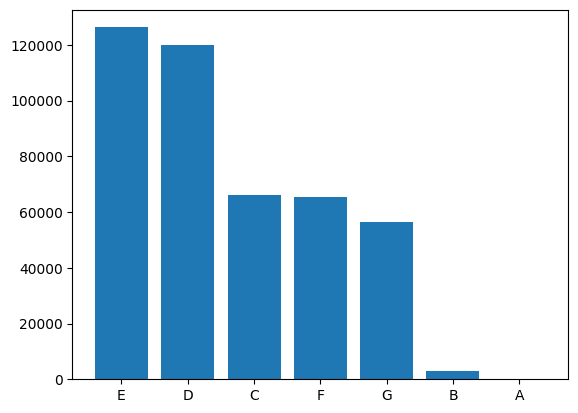

In [87]:
# distribution des logements en fonction des DPE
import matplotlib.pyplot as plt
import numpy as np

DPE = df_clean["Etiquette_DPE_ademe"].value_counts().index
count = df_clean["Etiquette_DPE_ademe"].value_counts()
fig, ax = plt.subplots()
ax.bar(DPE,count)

<Axes: >

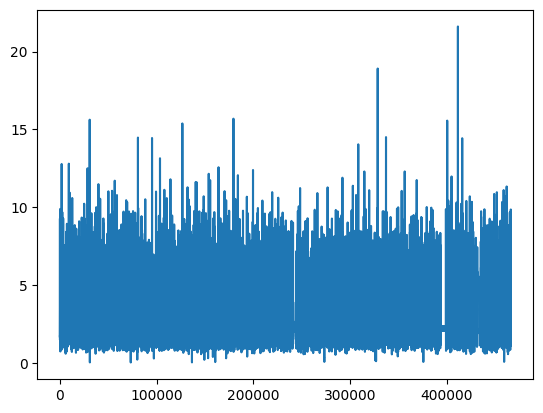

In [162]:
df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"].plot()

<Axes: >

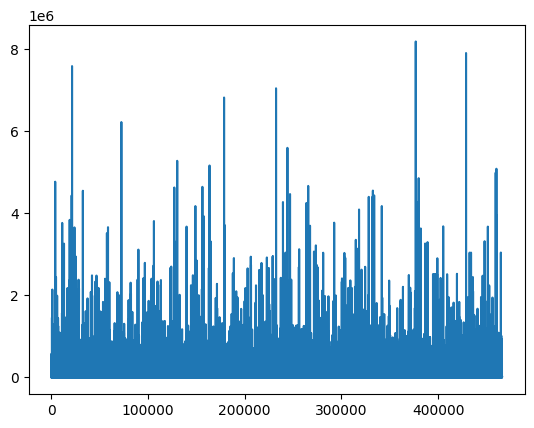

In [88]:
df["Conso_5_usages_é_primaire_ademe"].plot()

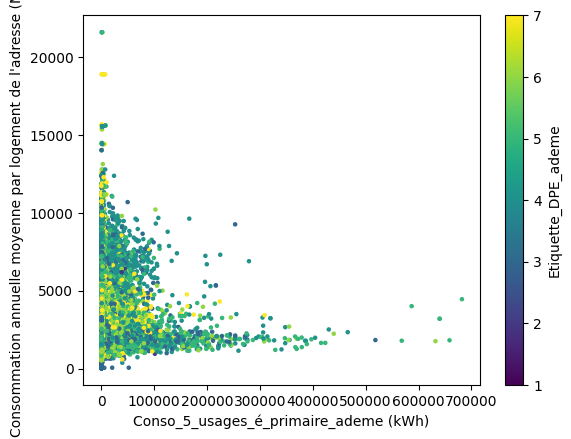

In [74]:
import matplotlib.pyplot as plt

# Convert categorical data to numerical values
color_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
colors = df_clean["Etiquette_DPE_ademe"].map(color_mapping)

plt.scatter(
    (df_clean["Conso_5_usages_é_primaire_ademe"]/12 ).round(2),
    df_clean["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"]*1000,
    c=colors,
    cmap='viridis',
    s=5)

plt.xlabel("Conso_5_usages_é_primaire_ademe (kWh)")
plt.ylabel("Consommation annuelle moyenne par logement de l'adresse (MWh)")
plt.colorbar(label='Etiquette_DPE_ademe')
plt.show()

In [107]:
(df_clean[["Conso_5_usages_é_primaire_ademe"]]/12).describe().round(3)
# Conso_5_usages_é_primaire_ademe : consommation annuelle  5 usages (ecs/chauffage/climatisation/eclairage/auxiliaires)en 
# energie finale(déduit de la production pv autoconsommée)  (kWhef/an)


,Conso_5_usages_é_primaire_ademe
count,437072.000
mean,1683.389
std,7836.890
min,34.875
25%,663.725
50%,976.592
75%,1391.708
max,681998.742


In [108]:
(df_clean[ ["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"]]*1000).describe().round(3)

,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban
count,437073.000
mean,2942.075
std,1506.101
min,30.000
25%,1868.000
50%,2661.000
75%,3538.000
max,21607.000
